# Задание Т2


1. Сгенерировать выборку объема N = 25 для экспоненциального распределения

In [2221]:
import numpy as np

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text

# Ручное моделирование через обратную функцию
N = 25
console = Console()
table = Table()

rand = np.random.random(N)
exp_samples = -np.log(1 - rand).round(4)
exp_samples.sort()

table.add_column(header="Выборка из 25 чисел:")

for n in exp_samples:
    table.add_row(str(n))

console.print(table)

┏━━━━━━━━━━━━━━━━━━━━━━┓
┃ Выборка из 25 чисел: ┃
┡━━━━━━━━━━━━━━━━━━━━━━┩
│ 0.0101               │
│ 0.0946               │
│ 0.1444               │
│ 0.1459               │
│ 0.1583               │
│ 0.1735               │
│ 0.2339               │
│ 0.3058               │
│ 0.3988               │
│ 0.4595               │
│ 0.5561               │
│ 0.5706               │
│ 0.6932               │
│ 0.779                │
│ 0.9138               │
│ 0.9469               │
│ 0.9717               │
│ 1.1311               │
│ 1.2014               │
│ 1.257                │
│ 1.7772               │
│ 2.0269               │
│ 2.5633               │
│ 3.1415               │
│ 4.221                │
└──────────────────────┘

А) Определить по выборке хар-ки: моду, медиану, размах, коэф. ассиметрии

In [2222]:
def calculate_skewness(data):

    data = np.asarray(data)
    size = len(data)
    
    if size < 3:
        return np.nan
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    
    if std == 0:
        return 0.0
    
    standardized = (data - mean) / std
    
    cubed_sum = np.sum(standardized ** 3)

    skewness = (size / ((size - 1) * (size - 2))) * cubed_sum
    
    return skewness


def calculate_mode(data):

    series_sort, counts = np.unique(exp_samples, return_counts=True)
    mode_index, count = np.argmax(counts), np.max(counts)

    if np.all(counts == 1):
        mode = None
        count = None
    else:
        mode = series_sort[mode_index]

    return(mode, count)

mode, count = calculate_mode(exp_samples)

med = np.median(exp_samples)

max_range = round(np.ptp(exp_samples), 4)

skw = round(calculate_skewness(exp_samples), 4)

table = Table()
console = Console()

for marker in ["Мода", "Медиана", "Размах", "Коэф. ассиметрии"]:
    table.add_column(str(marker))

table.add_row(str(mode), str(med), str(max_range), str(skw))

console.print(table)

┏━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Мода ┃ Медиана ┃ Размах ┃ Коэф. ассиметрии ┃
┡━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ None │ 0.6932  │ 4.2109 │ 1.7391           │
└──────┴─────────┴────────┴──────────────────┘

Б) Построить эмпирическую ф-ию распределения, гистограмму и boxplot (ящик с усами)

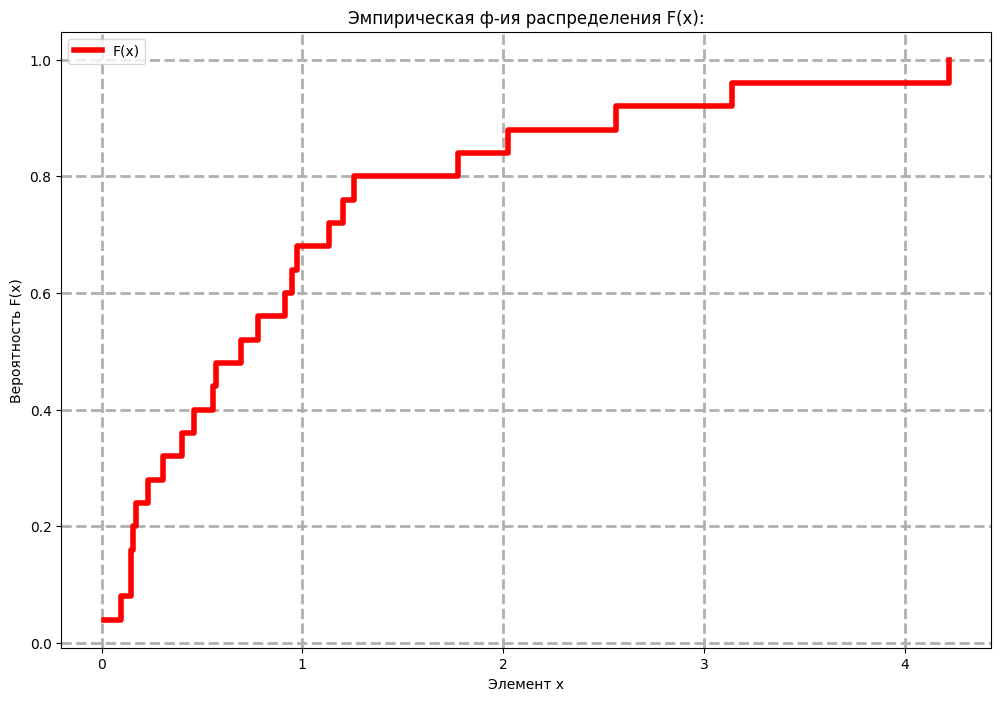

In [2223]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12,8))
ax.set_title("Эмпирическая ф-ия распределения F(x):")

Fx = np.arange(1, N + 1) / N
x = exp_samples

ax.step(x=x,
        y=Fx, 
        where='post', 
        linewidth=4, 
        color="r", 
        linestyle="-", 
        label="F(x)")
ax.grid(linewidth=2, which="major", linestyle="--")
ax.set_xlabel("Элемент x")
ax.set_ylabel("Вероятность F(x)")

ax.legend()
plt.show()

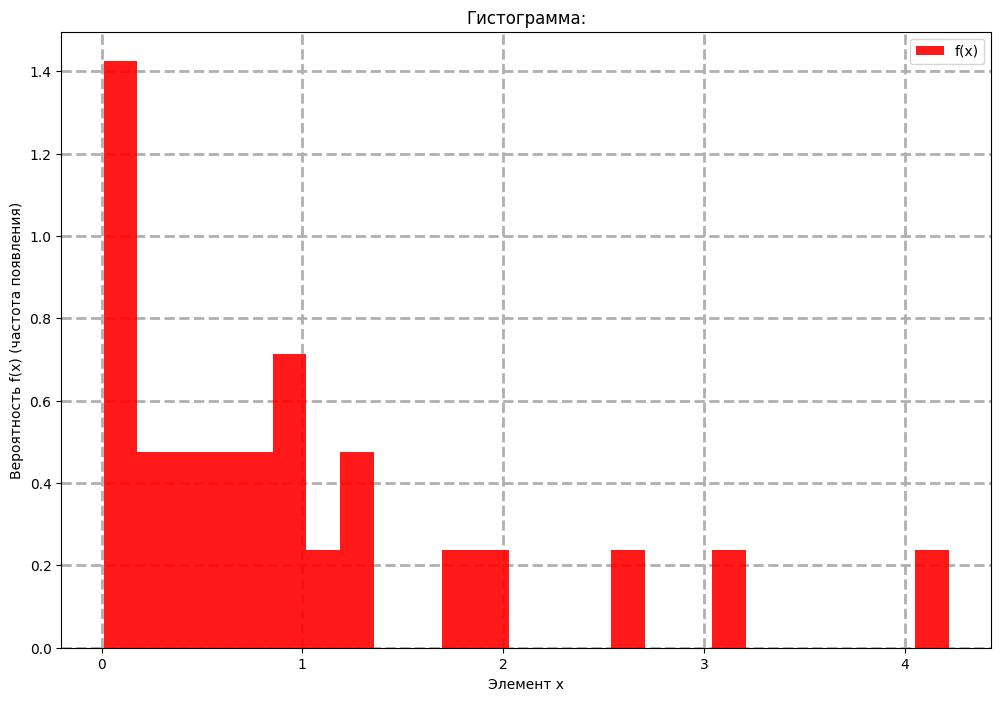

In [2224]:
from matplotlib.ticker import AutoMinorLocator

fig, ax = plt.subplots(1, 1, figsize=(12,8))
ax.set_title("Гистограмма:")

ax.hist(x,
         bins=N,
         color='r',
         label="f(x)",
         density=True,
         zorder=2,
         alpha=0.9,
         )

ax.grid(linewidth=2, which="major", linestyle="--", zorder=1)
ax.set_xlabel("Элемент x")
ax.set_ylabel("Вероятность f(x) (частота появления)")
ax.legend()

plt.show()

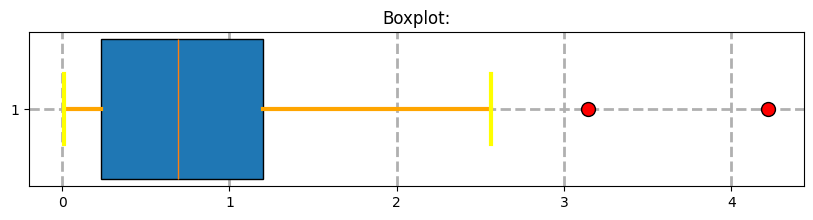

In [2225]:
fig, ax = plt.subplots(1, 1, figsize=(10,2))
ax.set_title("Boxplot:")

ax.boxplot(x=x,
           whiskerprops={"color": "orange", "linewidth": 3},
           capprops={"color": "yellow", "linewidth": 3},
           flierprops={'markerfacecolor': "red", 'markersize': 10},
           orientation="horizontal",
           widths=3,
           patch_artist=True,
           )
           
ax.grid(linewidth=2, which="major", linestyle="--", zorder=1)

C) Сравненить оценку плотности распределения mean из ЦПТ с бутстрапом.

Примечание: параметры норм. распределения получены в силу теоремы о наследовании нормальности 

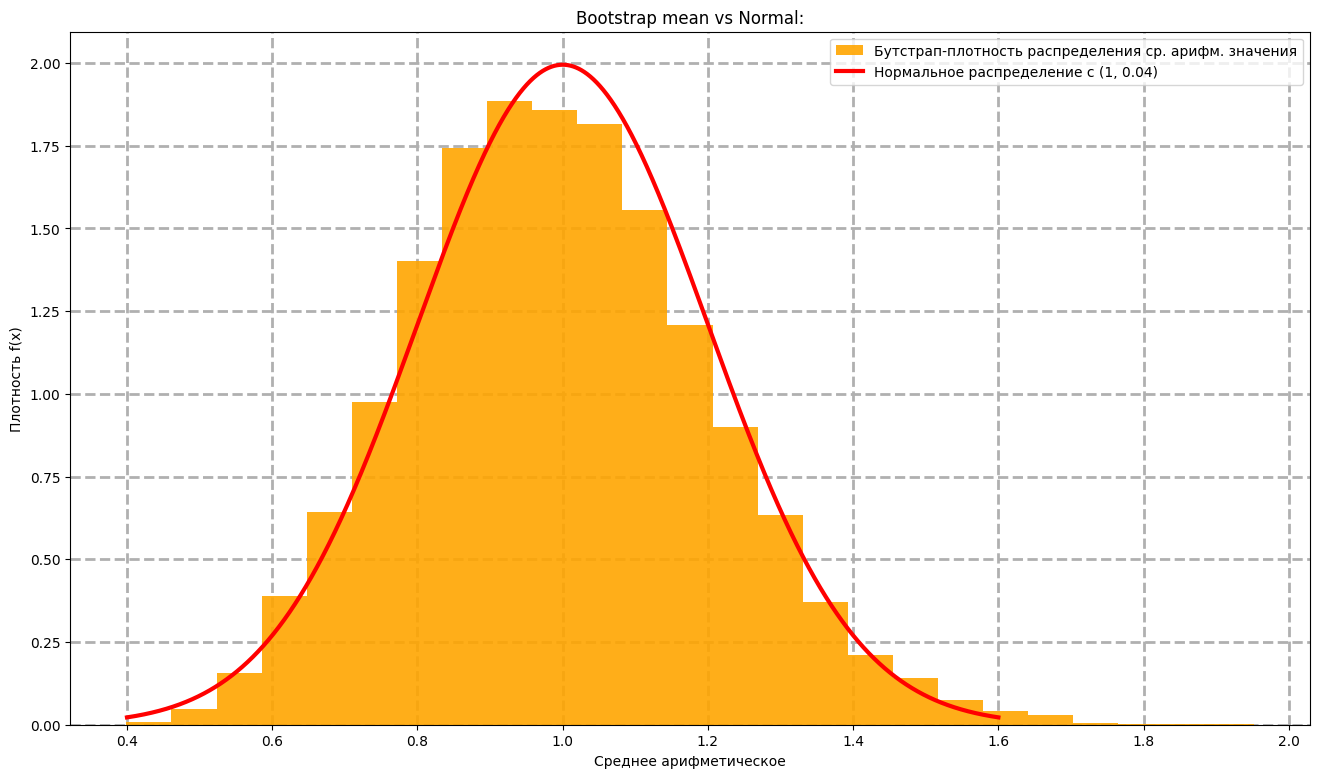

In [2226]:
import scipy as sp

fig, ax = plt.subplots(1, 1, figsize=(16,9))
ax.set_title("Bootstrap mean vs Normal:")

Mksi = 1
Mksi2 = 2
Dksi = Mksi2 - Mksi ** 2

bootstrap_iteration = 10000

mu = Mksi
sigma = 1 / N ** 0.5

x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, bootstrap_iteration)


ax.grid(linewidth=2, which="major", linestyle="--", zorder=1)
ax.set_xlabel("Среднее арифметическое")
ax.set_ylabel("Плотность f(x)")

n = len(exp_samples)
bootstrap_means = []

for i in range(bootstrap_iteration):
    indices = np.random.choice(n, size=n, replace=True)
    bootstrap_sample = exp_samples[indices]
    bootstrap_means.append(np.mean(bootstrap_sample))

ax.hist(bootstrap_means,
         bins=N,
         color='orange',
         label="Бутстрап-плотность распределения ср. арифм. значения",
         density=True,
         zorder=2,
         alpha=0.9)

ax.plot(x,
         sp.stats.norm.pdf(x, mu, sigma),
         label=f"Нормальное распределение с ({Mksi}, {round(sigma ** 2, 2)})",
         color='red',
         linewidth=3,
         zorder=2)

plt.legend()
plt.show()


D) Найти бустраповскую оценку плотности распределения коэф-а асимметрии и оценить веротяность, что он будет меньше 1

Вероятность, что коэф-т асимметрии < 1: 0.6198


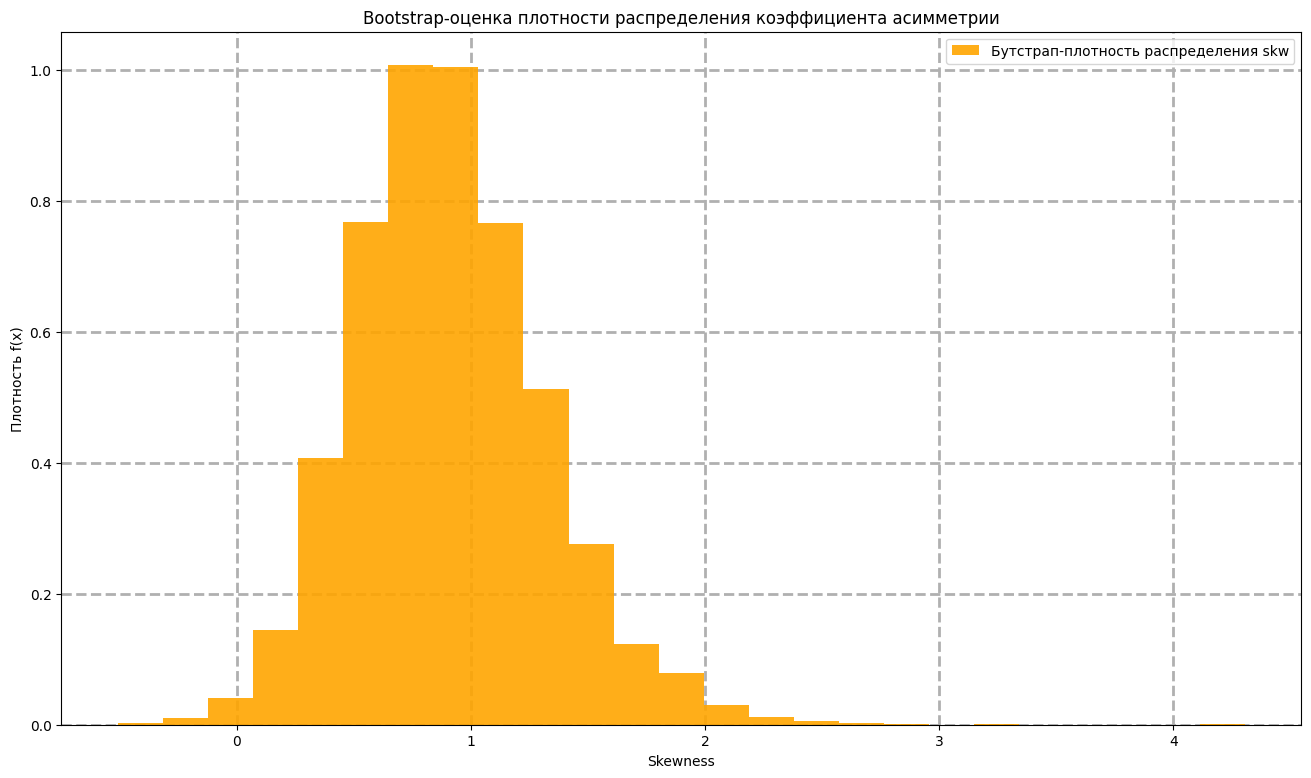

In [2220]:
bootstrap_skw = []
skw_treshold = 1

fig, ax = plt.subplots(1, 1, figsize=(16,9))

for i in range(bootstrap_iteration):
    indices = np.random.choice(n, size=n, replace=True)
    bootstrap_sample = exp_samples[indices]
    bootstrap_skw.append(calculate_skewness(bootstrap_sample))

ax.set_title("Bootstrap-оценка плотности распределения коэффициента асимметрии")
ax.set_xlabel("Skewness")
ax.set_ylabel("Плотность f(x)")

ax.grid(linewidth=2, which="major", linestyle="--", zorder=1)

ax.hist(bootstrap_skw,
         bins=N,
         color='orange',
         label="Бутстрап-плотность распределения skw",
         density=True,
         zorder=2,
         alpha=0.9
         )

skw_treshold_prob = sum([1 for i in bootstrap_skw if i < skw_treshold]) / bootstrap_iteration

print(f"Вероятность, что коэф-т асимметрии < {skw_treshold}: {skw_treshold_prob}")

plt.legend()
plt.show()

E) Сравнить плотности распределения медианы выборки с бутсраповской оценкой

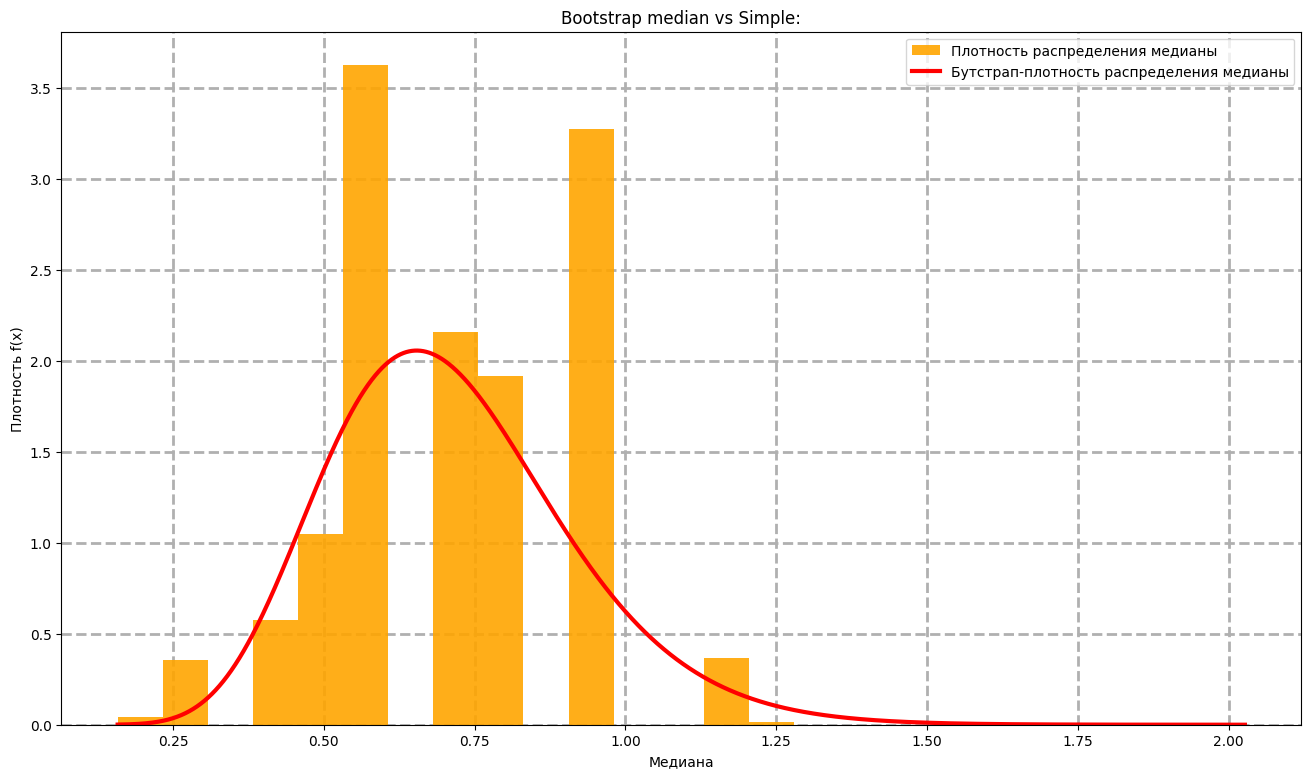

In [2227]:
fig, ax = plt.subplots(1, 1, figsize=(16,9))
ax.set_title("Bootstrap median vs Simple:")

def f(x: float) -> float:
  return np.exp(-x) if x >= 0 else 0

def F(x: float) -> float:
  return (1 - np.exp(-x)) if x >= 0 else 0

# Распр. порядковых статистик
def med_distrib(x):
  k = N // 2 + 1
  return N * f(x) * sp.special.comb(N - 1, k - 1) * ((1 - F(x)) ** (N - k)) * (F(x) ** (k - 1))

ax.grid(linewidth=2, which="major", linestyle="--", zorder=1)
ax.set_xlabel("Медиана")
ax.set_ylabel("Плотность f(x)")

n = len(exp_samples)
bootstrap_medians = []

for i in range(bootstrap_iteration):
    indices = np.random.choice(n, size=n, replace=True)
    bootstrap_sample = exp_samples[indices]
    bootstrap_medians.append(np.median(bootstrap_sample))

x = np.linspace(min(bootstrap_medians),
                max(bootstrap_medians),
                bootstrap_iteration)

ax.hist(bootstrap_medians,
         bins=N,
         color='orange',
         label="Плотность распределения медианы",
         density=True,
         zorder=2,
         alpha=0.9)

ax.plot(x,
         [med_distrib(x_i) for x_i in x],
         label="Бутстрап-плотность распределения медианы",
         color="red",
         linewidth=3)

plt.legend()
ax.legend()
plt.show()
